Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report,
                             ConfusionMatrixDisplay,
                             confusion_matrix)
import joblib

# Install sentence-transformers if not already installed
import subprocess
subprocess.run(['pip', 'install', 'sentence-transformers', '-q'])

print("All imports successful!")

All imports successful!


Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/CSE572_Project/'

train_df = pd.read_csv(path + 'train.csv')
val_df   = pd.read_csv(path + 'val.csv')
test_df  = pd.read_csv(path + 'test.csv')
classes  = np.load(path + 'label_classes.npy', allow_pickle=True)

X_train = train_df['text'].fillna('')
X_val   = val_df['text'].fillna('')
X_test  = test_df['text'].fillna('')
y_train = train_df['label']
y_val   = val_df['label']
y_test  = test_df['label']

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: 1738 | Val: 373 | Test: 373


Load Sentence-BERT and generate embeddings

In [ ]:
# Generate Sentence-BERT Embeddings:
# all-MiniLM-L6-v2 is a lightweight but strong SBERT model
# 384-dimensional embeddings, fast inference, good semantic quality

print("Loading Sentence-BERT model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Encoding training set (this will take a few minutes)...")
X_train_emb = model.encode(
    X_train.tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Encoding validation set...")
X_val_emb = model.encode(
    X_val.tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Encoding test set...")
X_test_emb = model.encode(
    X_test.tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print(f"\nEmbedding shapes:")
print(f"  Train: {X_train_emb.shape}")
print(f"  Val:   {X_val_emb.shape}")
print(f"  Test:  {X_test_emb.shape}")

Loading Sentence-BERT model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Encoding validation set...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Encoding test set...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]


Embedding shapes:
  Train: (1738, 384)
  Val:   (373, 384)
  Test:  (373, 384)


Saving Embeddings to Drive

In [ ]:
# Save Embeddings to Drive:
# IMPORTANT: Save immediately after generating
# so you never have to rerun the expensive encoding step

np.save(path + 'sbert_train_emb.npy', X_train_emb)
np.save(path + 'sbert_val_emb.npy',   X_val_emb)
np.save(path + 'sbert_test_emb.npy',  X_test_emb)

print("Embeddings saved to Drive:")
print("  sbert_train_emb.npy")a
print("  sbert_val_emb.npy")
print("  sbert_test_emb.npy")
print("\nWe can now load these directly in future sessions")
print("without re-running the encoding step.")

Embeddings saved to Drive:
  sbert_train_emb.npy
  sbert_val_emb.npy
  sbert_test_emb.npy

We can now load these directly in future sessions
without re-running the encoding step.


Training MLP classifier

In [ ]:
# MLP Classifier on SBERT Embeddings:
# Two hidden layers of 512 and 256 neurons
# relu activation, adam optimizer
# early stopping to prevent overfitting

mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256),
    activation='relu',
    solver='adam',
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=True
)

print("Training MLP classifier...")
mlp.fit(X_train_emb, y_train)

val_preds = mlp.predict(X_val_emb)

print("\n=== Semantic Agent MLP (Validation) ===")
print(f"Accuracy:    {accuracy_score(y_val, val_preds):.4f}")
print(f"Macro F1:    {f1_score(y_val, val_preds, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_val, val_preds, average='weighted'):.4f}")
print("\nPer-class report:")
print(classification_report(y_val, val_preds,
                            target_names=classes,
                            zero_division=0))

Training MLP classifier...
Iteration 1, loss = 3.12514902
Validation score: 0.321839
Iteration 2, loss = 2.90769808
Validation score: 0.442529
Iteration 3, loss = 2.59415953
Validation score: 0.494253
Iteration 4, loss = 2.20633981
Validation score: 0.545977
Iteration 5, loss = 1.84433248
Validation score: 0.551724
Iteration 6, loss = 1.57795440
Validation score: 0.597701
Iteration 7, loss = 1.40423788
Validation score: 0.626437
Iteration 8, loss = 1.27941209
Validation score: 0.643678
Iteration 9, loss = 1.19216808
Validation score: 0.678161
Iteration 10, loss = 1.12225359
Validation score: 0.649425
Iteration 11, loss = 1.06922954
Validation score: 0.660920
Iteration 12, loss = 1.01996137
Validation score: 0.678161
Iteration 13, loss = 0.97305208
Validation score: 0.666667
Iteration 14, loss = 0.93356634
Validation score: 0.695402
Iteration 15, loss = 0.89192178
Validation score: 0.683908
Iteration 16, loss = 0.85744433
Validation score: 0.695402
Iteration 17, loss = 0.81903888
Valida

Confusion Matrix

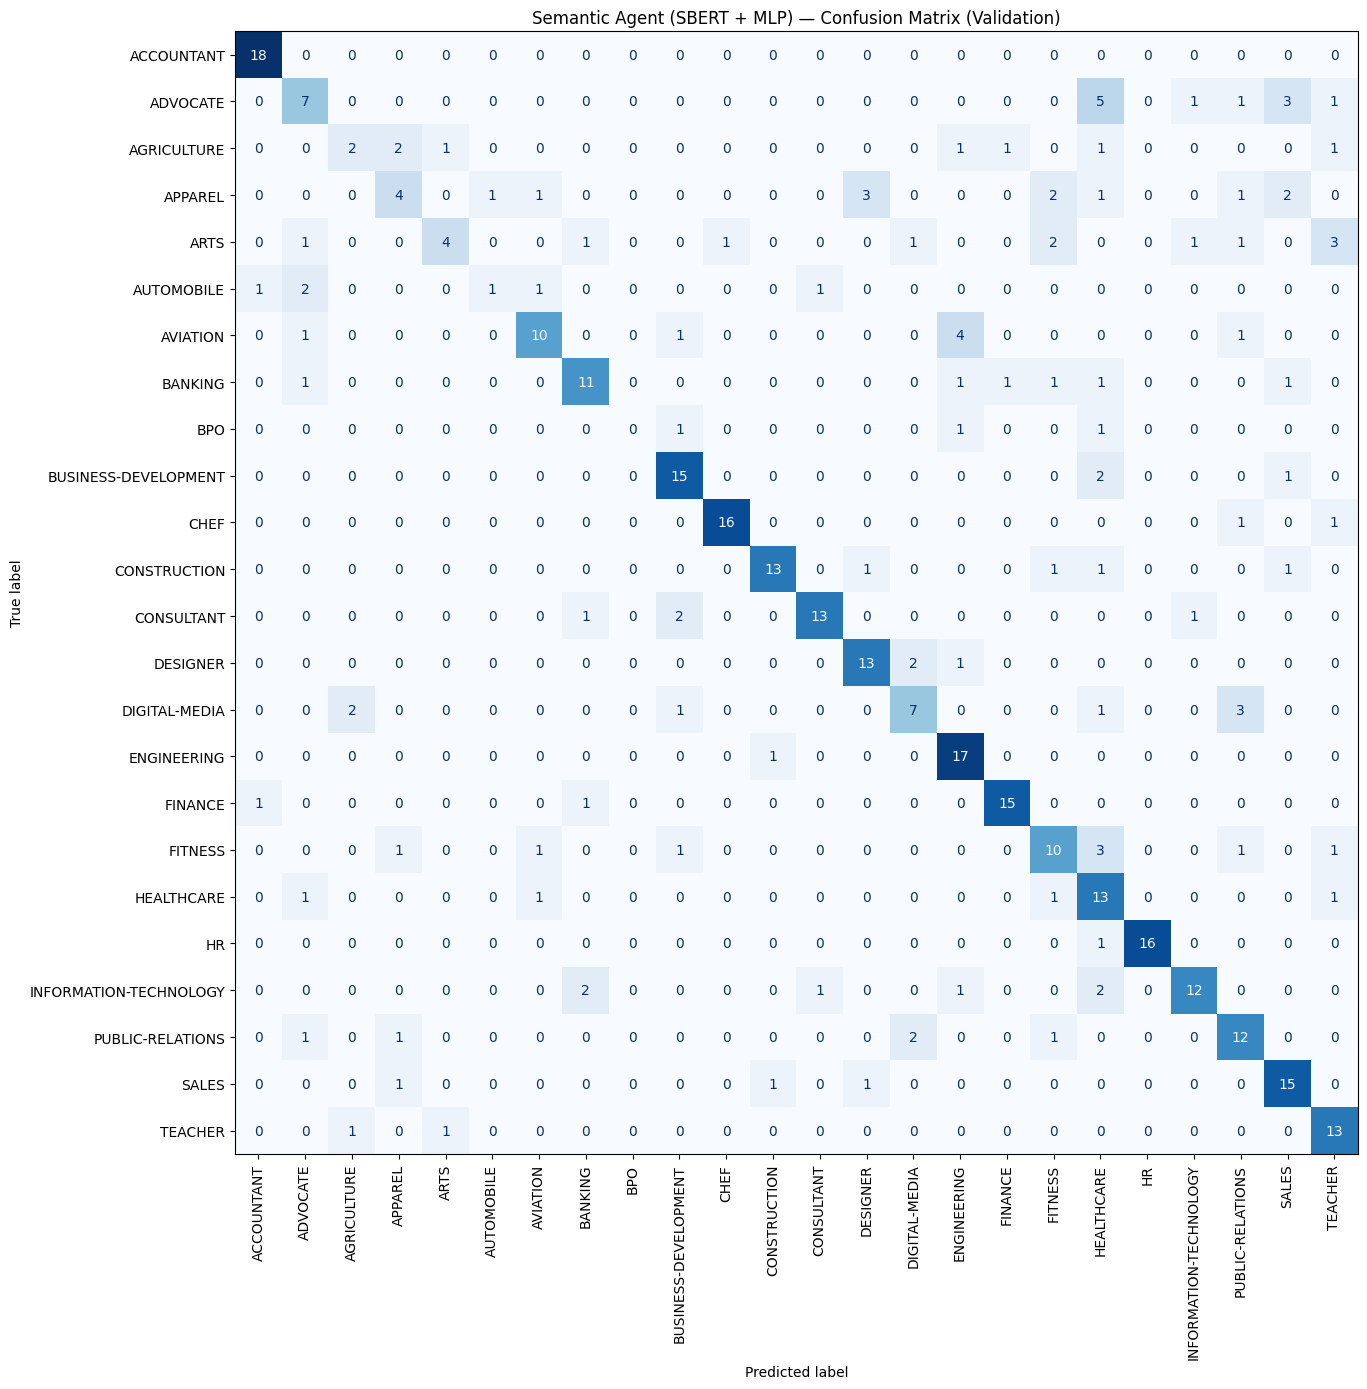

In [ ]:
fig, ax = plt.subplots(figsize=(16, 14))
cm = confusion_matrix(y_val, val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=classes)
disp.plot(ax=ax, xticks_rotation=90, colorbar=False, cmap='Blues')
ax.set_title('Semantic Agent (SBERT + MLP) — Confusion Matrix (Validation)')
plt.tight_layout()
plt.savefig(path + 'semantic_confusion_matrix.png', dpi=150)
plt.show()

Test Evaluation & Save

In [ ]:
test_preds = mlp.predict(X_test_emb)

print("=== Semantic Agent MLP (Test Set - Final) ===")
print(f"Accuracy:    {accuracy_score(y_test, test_preds):.4f}")
print(f"Macro F1:    {f1_score(y_test, test_preds, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_test, test_preds, average='weighted'):.4f}")

# Save model
joblib.dump(mlp, path + 'semantic_mlp.pkl')

# Saving probability outputs for fusion agent
train_proba = mlp.predict_proba(X_train_emb)
val_proba   = mlp.predict_proba(X_val_emb)
test_proba  = mlp.predict_proba(X_test_emb)

np.save(path + 'semantic_train_proba.npy', train_proba)
np.save(path + 'semantic_val_proba.npy',   val_proba)
np.save(path + 'semantic_test_proba.npy',  test_proba)

print("\nSaved:")
print("  semantic_mlp.pkl")
print("  semantic_train/val/test_proba.npy")

=== Semantic Agent MLP (Test Set - Final) ===
Accuracy:    0.7051
Macro F1:    0.6343
Weighted F1: 0.6867

Saved:
  semantic_mlp.pkl
  semantic_train/val/test_proba.npy
